# 04 — Trend & Correlation Analysis

**Objective:** Quantify growth rates using trend analysis (linear regression, polynomial regression, moving averages, Mann-Kendall test) and understand relationships via correlation analysis (Pearson, Spearman, ACF, PACF, cross-correlation).

**Dataset:** `fact_sessions_clean.csv` — 472,871 website sessions (March 2012 – March 2015)

**Metrics analysed (daily aggregation):**
| Metric | Column | Description |
|--------|--------|-------------|
| Conversion Rate | `conv_rate` | orders / sessions |
| Revenue per Session | `revenue_per_session` | revenue / sessions |
| Average Order Value | `aov` | revenue / orders |
| Order Volume | `orders` | daily converted sessions |
| Session Volume | `sessions` | daily session count |

In [1]:
# ── Imports & Configuration ──────────────────────────────────────────────
import sys, os, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make project scripts importable
sys.path.insert(0, os.path.abspath("../scripts"))
from trend_utils import (
    fit_linear_trend, fit_polynomial_trend, compute_moving_averages,
    mann_kendall_test, compute_correlations, compute_cross_correlation,
    plot_trend_regression, plot_moving_averages, plot_acf_pacf,
    plot_cross_correlation, build_trend_summary, build_correlation_summary,
)

# Plotting defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
pd.options.display.float_format = "{:.4f}".format

# Paths
INPUT_PATH = "../data/processed/fact_sessions_clean.csv"
GRAPHS_PATH = "../graphs"
DOCS_PATH = "../docs"
os.makedirs(GRAPHS_PATH, exist_ok=True)
os.makedirs(DOCS_PATH, exist_ok=True)

# Metrics to analyse
METRICS = {
    "conv_rate": "Conversion Rate",
    "revenue_per_session": "Revenue per Session (RPS)",
    "aov": "Average Order Value (AOV)",
    "orders": "Order Volume",
    "sessions": "Session Volume",
}

print("Setup complete ✓")

Setup complete ✓


## 1. Load Data & Build Daily Aggregation

In [2]:
# Load session-level data
fact = pd.read_csv(INPUT_PATH, parse_dates=["date"])
print(f"Loaded {fact.shape[0]:,} rows  |  Date range: {fact['date'].min().date()} → {fact['date'].max().date()}")

# Daily aggregation
daily = fact.groupby("date").agg(
    sessions=("is_converted", "count"),
    orders=("is_converted", "sum"),
    revenue=("price_usd", "sum"),
).reset_index()

daily["conv_rate"] = daily["orders"] / daily["sessions"]
daily["revenue_per_session"] = daily["revenue"] / daily["sessions"]
daily["aov"] = daily["revenue"] / daily["orders"]
# AOV is undefined (0/0) on days with zero orders → fill with 0
daily["aov"] = daily["aov"].replace([np.inf, -np.inf], np.nan).fillna(0)

daily = daily.sort_values("date").reset_index(drop=True)
print(f"Daily dataframe: {daily.shape[0]} days, columns: {list(daily.columns)}")
daily.head()

Loaded 472,871 rows  |  Date range: 2012-03-19 → 2015-03-19
Daily dataframe: 1096 days, columns: ['date', 'sessions', 'orders', 'revenue', 'conv_rate', 'revenue_per_session', 'aov']


,date,sessions,orders,revenue,conv_rate,revenue_per_session,aov
0,2012-03-19,137,2,99.9800,0.0146,0.7298,49.9900
1,2012-03-20,161,6,299.9400,0.0373,1.8630,49.9900
2,2012-03-21,191,9,449.9100,0.0471,2.3555,49.9900
3,2012-03-22,177,4,199.9600,0.0226,1.1297,49.9900
4,2012-03-23,156,3,149.9700,0.0192,0.9613,49.9900


---
## 2. Trend Analysis

### Why these methods?
| Method | Purpose |
|--------|---------|
| **Linear Regression** | Quantify the average daily growth rate (slope) and test its significance |
| **Polynomial Regression (deg 2)** | Capture curvature — does growth accelerate or decelerate? |
| **Moving Averages (7, 30, 90 day)** | Smooth daily noise to reveal the underlying trend |
| **Mann-Kendall Test** | Non-parametric trend detector — no normality assumption required |

### 2.1 Trend Summary Table
Compute linear regression, polynomial regression, and Mann-Kendall results for every metric in a single summary.

In [3]:
# Build consolidated trend summary
trend_summary = build_trend_summary(daily, METRICS)
trend_summary

,Metric,Linear Slope,Linear R²,Linear p-value,Poly R²,MK Trend,MK p-value
0,Conversion Rate,0.0000,0.4446,0.0000,0.4801,increasing,0.0000
1,Revenue per Session (RPS),0.0035,0.6425,0.0000,0.6491,increasing,0.0000
2,Average Order Value (AOV),0.0185,0.6338,0.0000,0.6356,increasing,0.0000
3,Order Volume,0.0613,0.4603,0.0000,0.4863,increasing,0.0000
4,Session Volume,0.6880,0.3533,0.0000,0.3679,increasing,0.0000


### 2.2 Linear & Polynomial Regression Plots
For each metric we overlay the linear fit (red) and quadratic polynomial fit (green dashed) on the raw daily data.

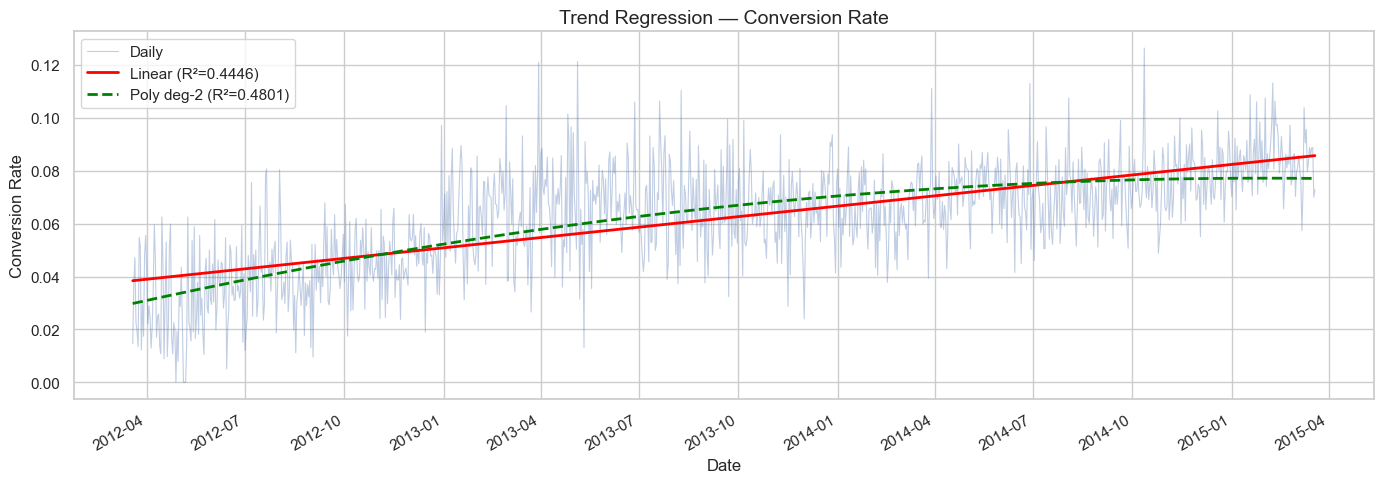

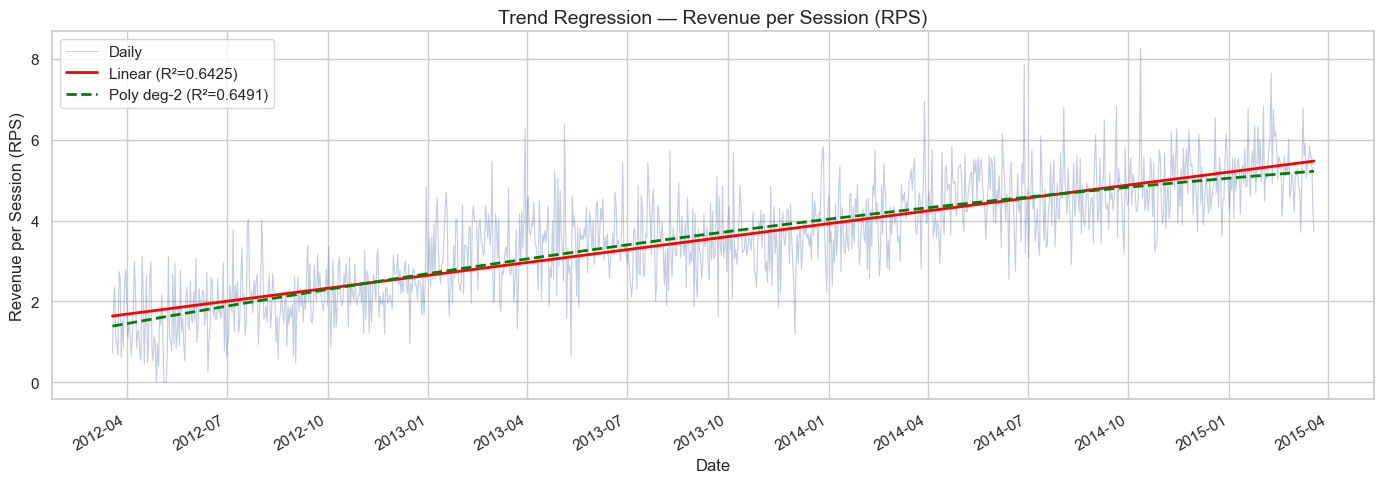

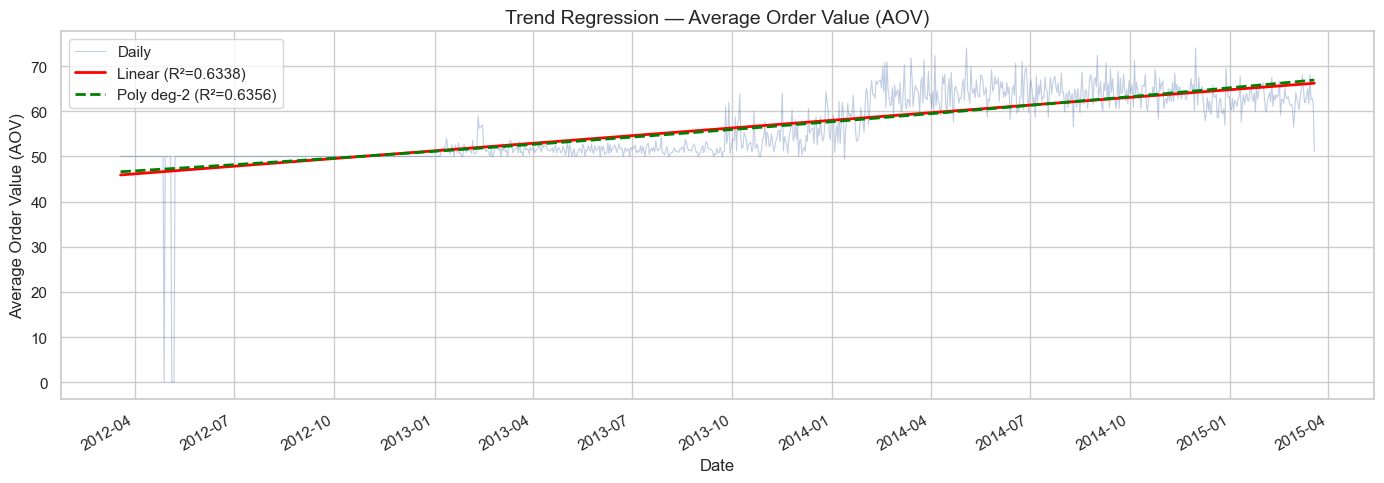

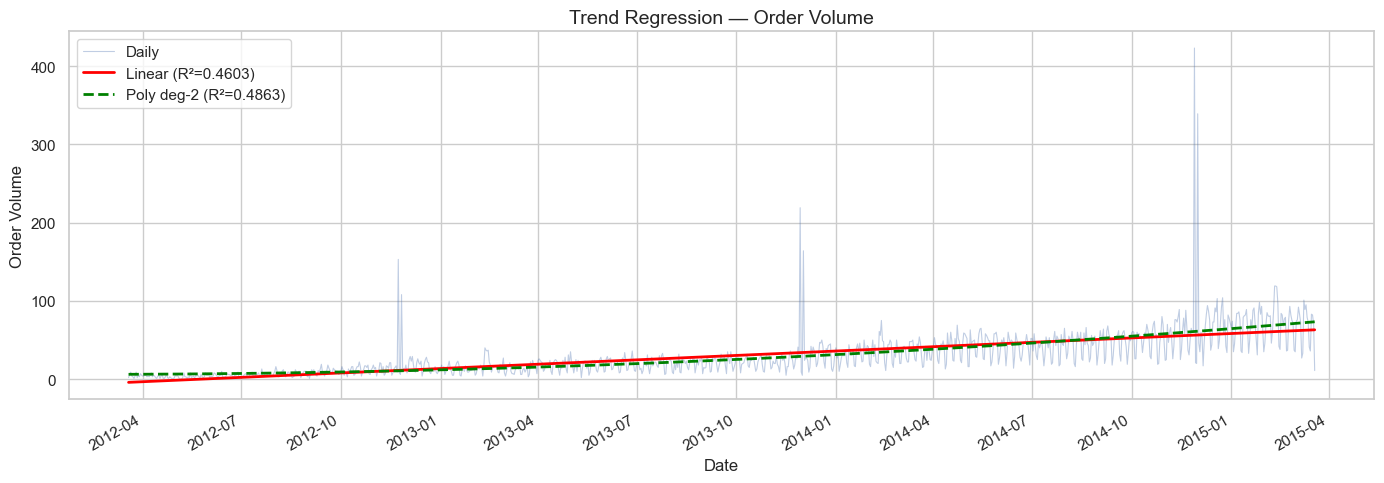

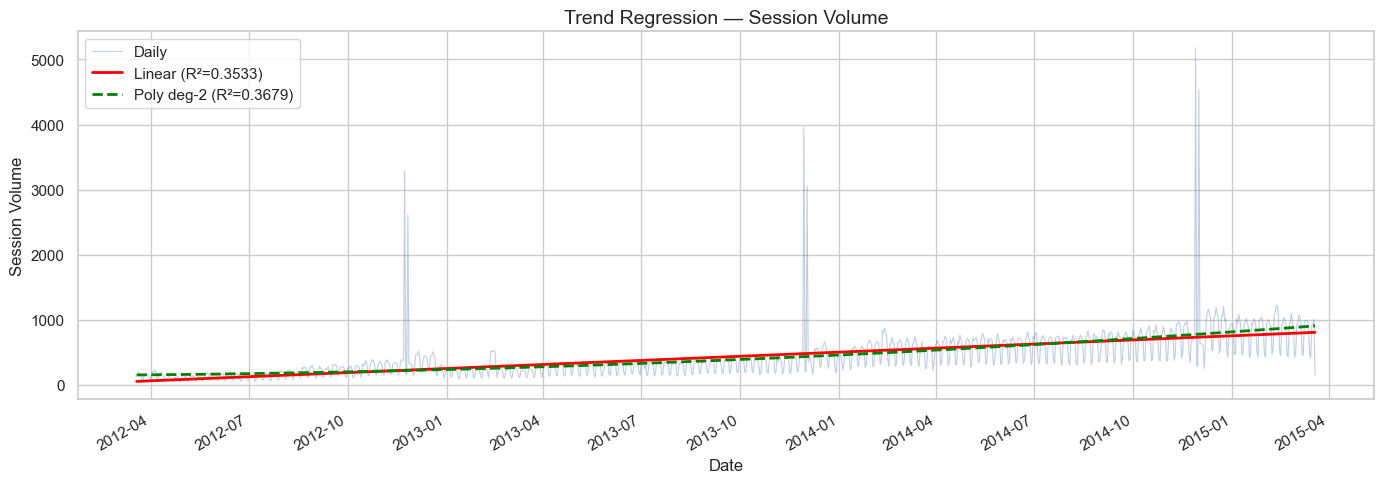

In [4]:
# Generate regression plots for all metrics
for col, label in METRICS.items():
    save_name = f"trend_regression_{col}.png"
    plot_trend_regression(daily, col, label,
                          save_path=os.path.join(GRAPHS_PATH, save_name))

### 2.3 Moving Averages (7-day, 30-day, 90-day)
Smoothing daily noise with rolling windows to reveal the underlying trend shape.

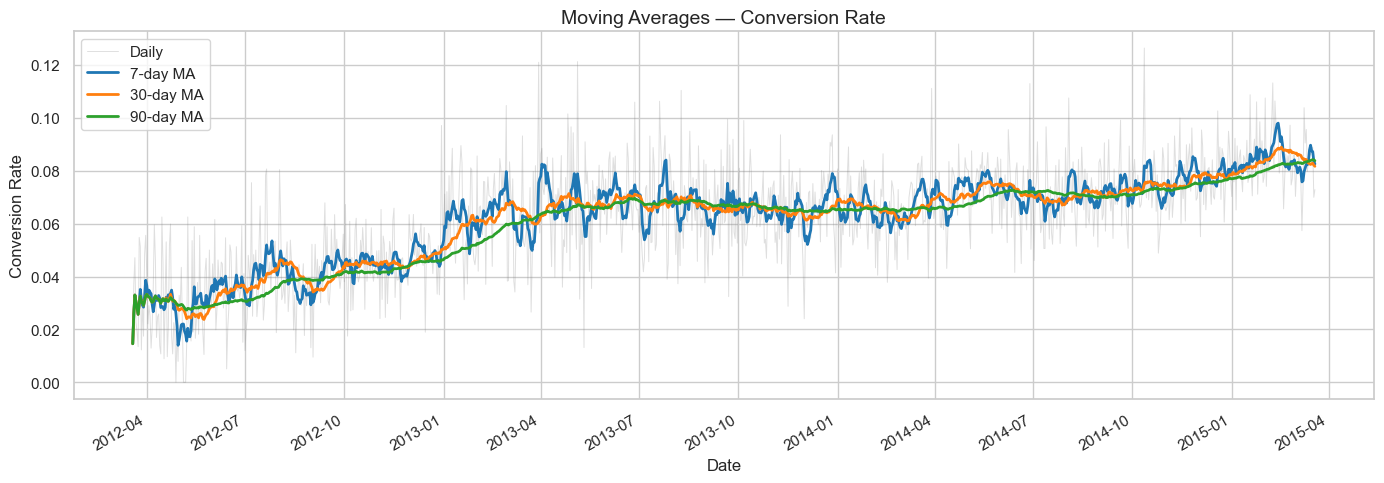

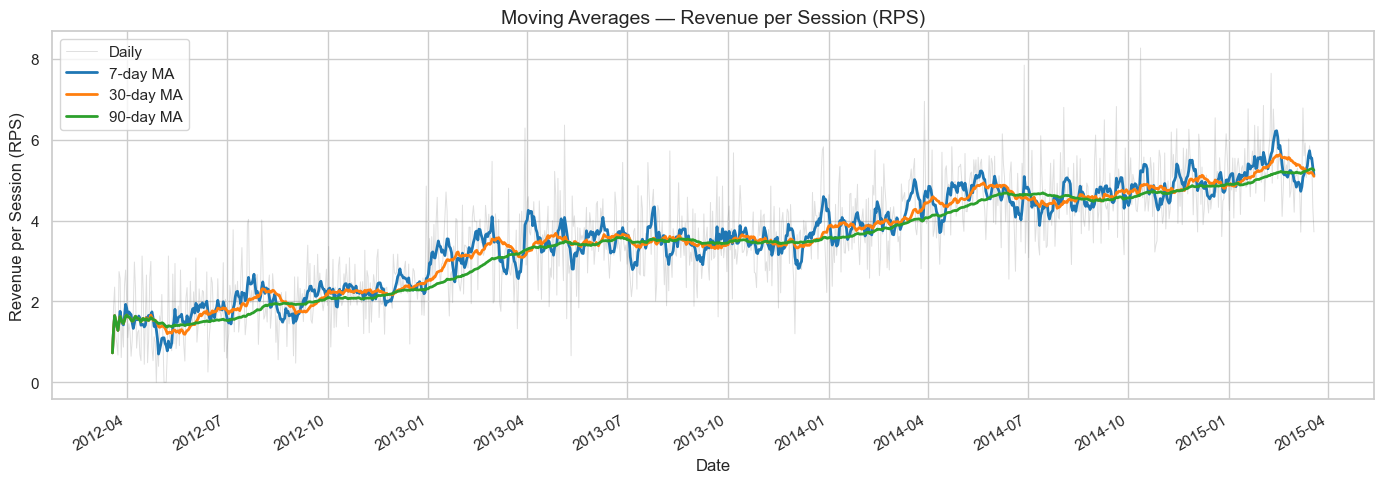

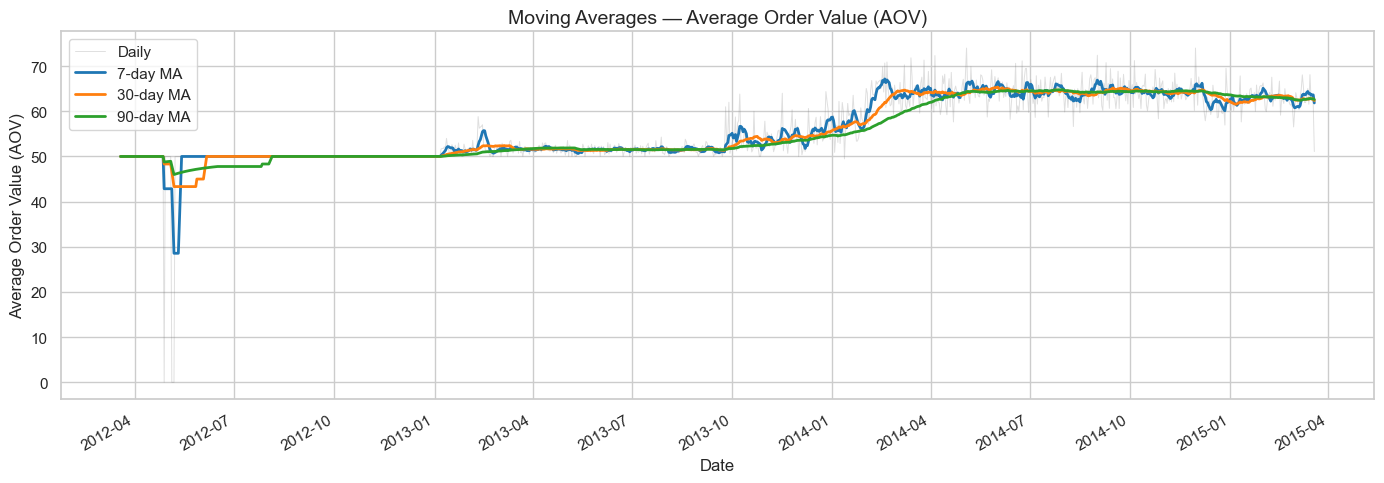

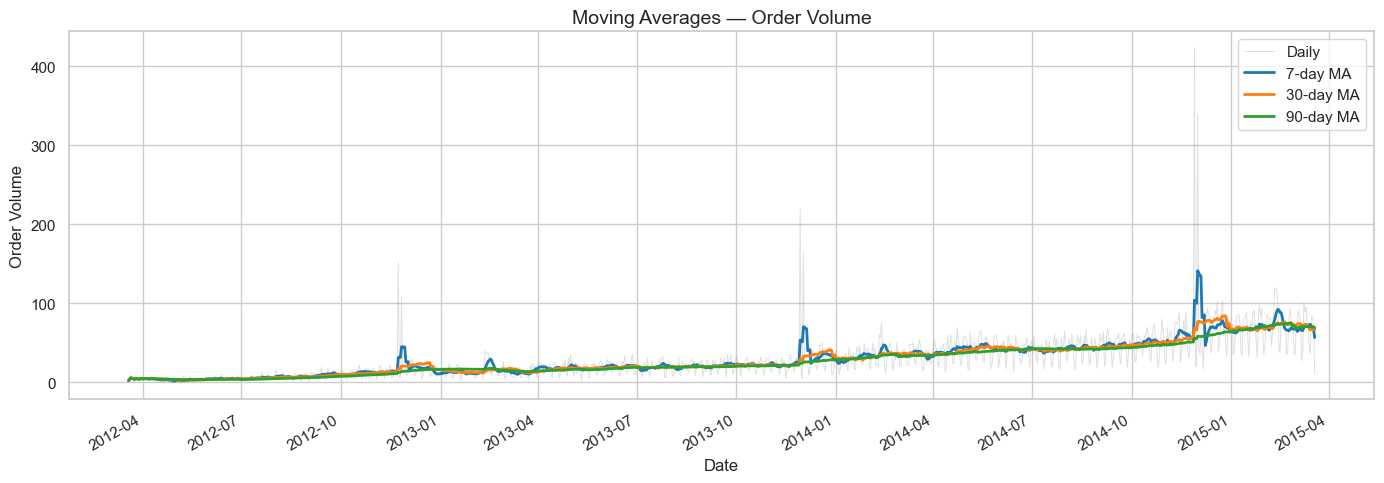

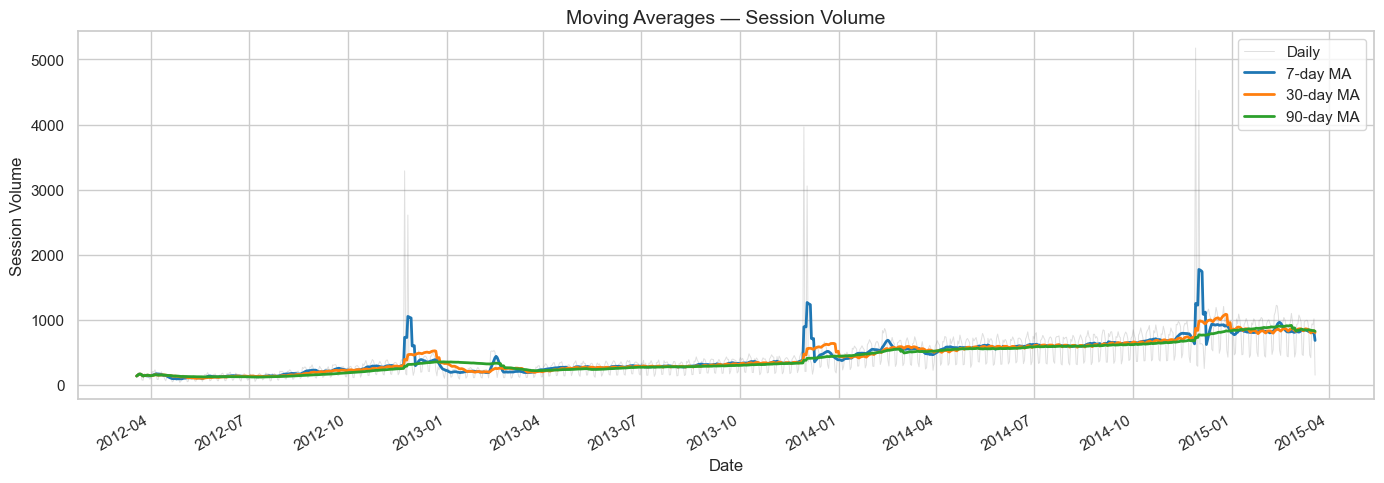

In [5]:
# Generate moving average plots for all metrics
for col, label in METRICS.items():
    save_name = f"moving_averages_{col}.png"
    plot_moving_averages(daily, col, label,
                         save_path=os.path.join(GRAPHS_PATH, save_name))

---
## 3. Correlation Analysis

### Why these methods?
| Method | Purpose |
|--------|---------|
| **Pearson Correlation** | Measures the *linear* relationship between a numeric time index and the metric |
| **Spearman Correlation** | Measures *monotonic* (rank-based) relationship — robust to non-linearity |
| **ACF (Autocorrelation)** | How today's value correlates with past values — reveals momentum / periodicity |
| **PACF (Partial Autocorrelation)** | Direct lag effect after removing indirect effects — guides ARIMA lag order |
| **Cross-Correlation** | Relationship between two different series at various lags (e.g., sessions vs conversion rate) |

### 3.1 Pearson & Spearman Correlation Summary

In [6]:
# Correlation of each metric against numeric time index
corr_summary = build_correlation_summary(daily, METRICS)
corr_summary

,Metric,Pearson r,Pearson p-value,Spearman ρ,Spearman p-value
0,Conversion Rate,0.6668,0.0000,0.6642,0.0000
1,Revenue per Session (RPS),0.8016,0.0000,0.8106,0.0000
2,Average Order Value (AOV),0.7961,0.0000,0.8863,0.0000
3,Order Volume,0.6785,0.0000,0.8599,0.0000
4,Session Volume,0.5944,0.0000,0.8166,0.0000


### 3.2 ACF & PACF Plots
Autocorrelation and partial autocorrelation at up to 30 lags for each metric.

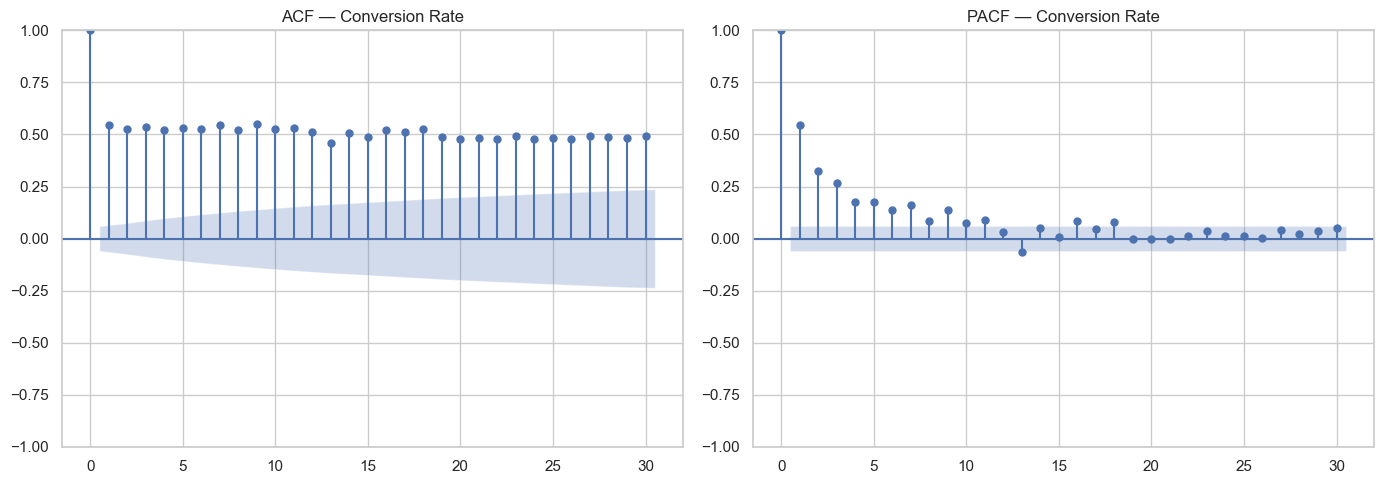

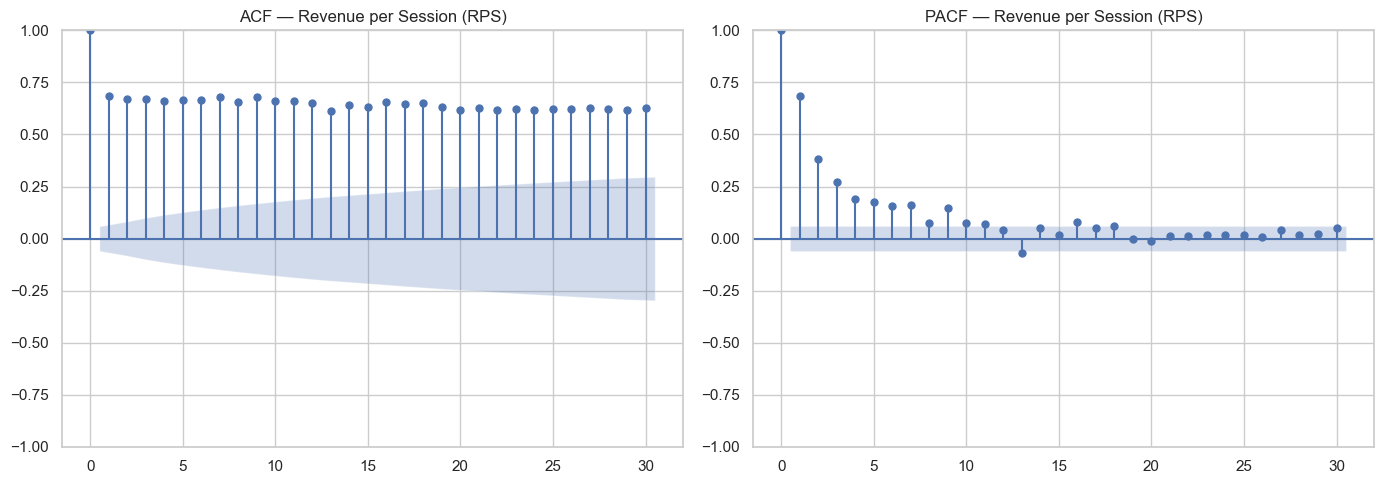

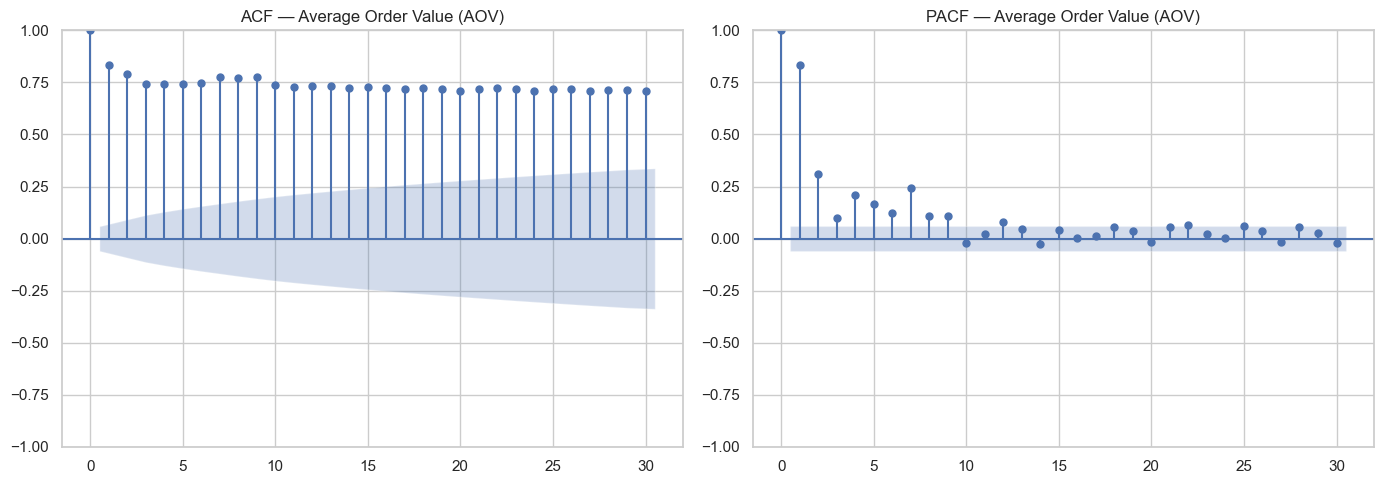

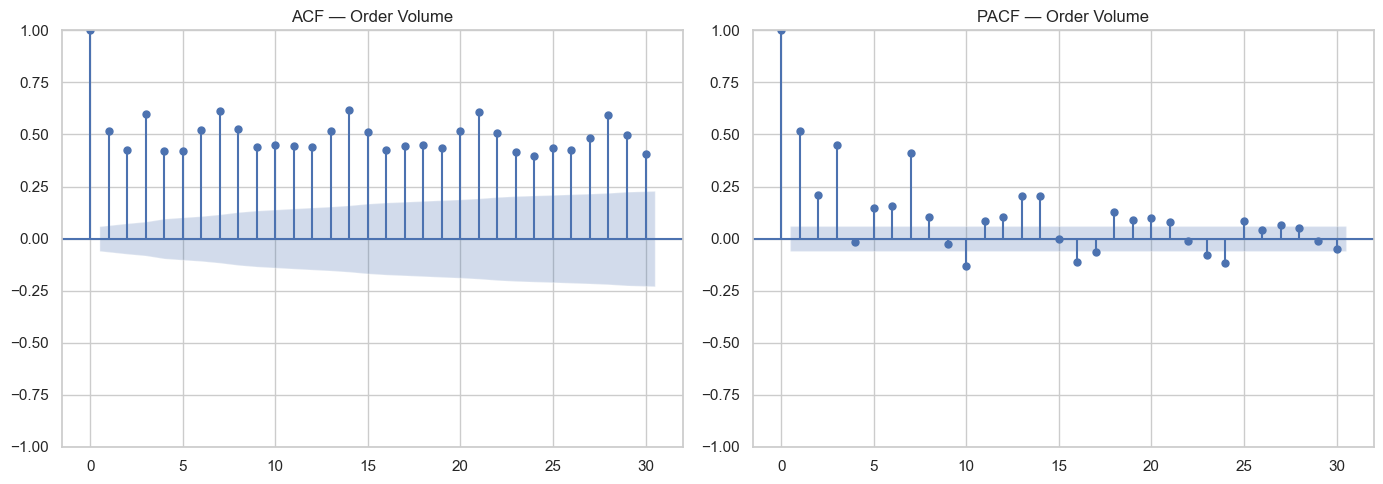

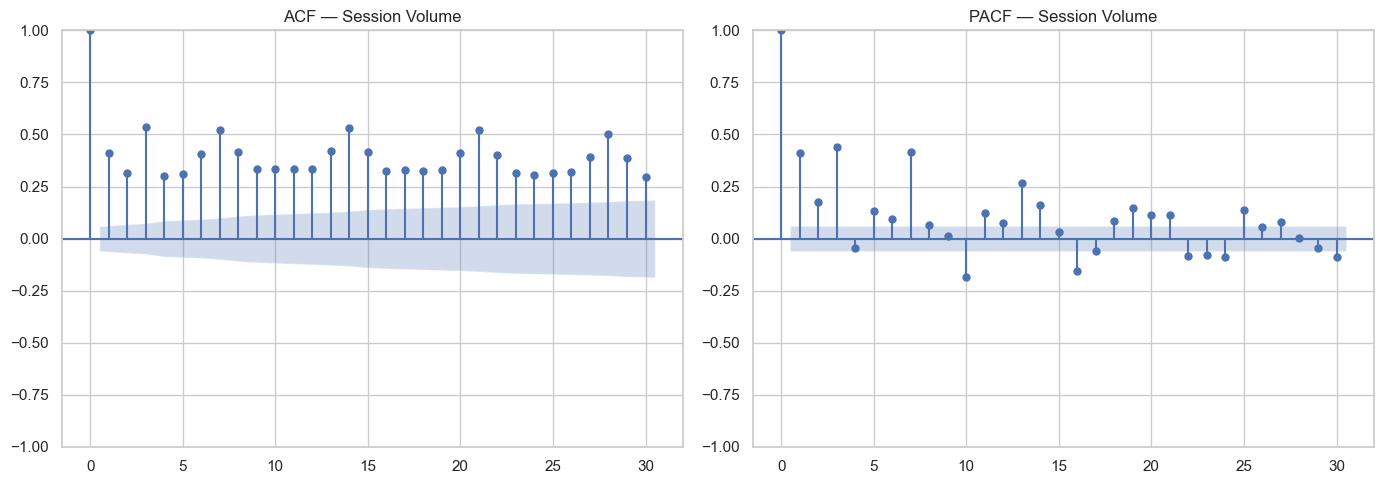

In [7]:
# Generate ACF/PACF plots for all metrics
for col, label in METRICS.items():
    save_name = f"acf_pacf_{col}.png"
    plot_acf_pacf(daily[col], label, lags=30,
                  save_path=os.path.join(GRAPHS_PATH, save_name))

### 3.3 Cross-Correlation: Conversion Rate vs Session Volume
Using session volume as a proxy for traffic intensity, we check whether higher traffic days lead or lag changes in conversion rate.

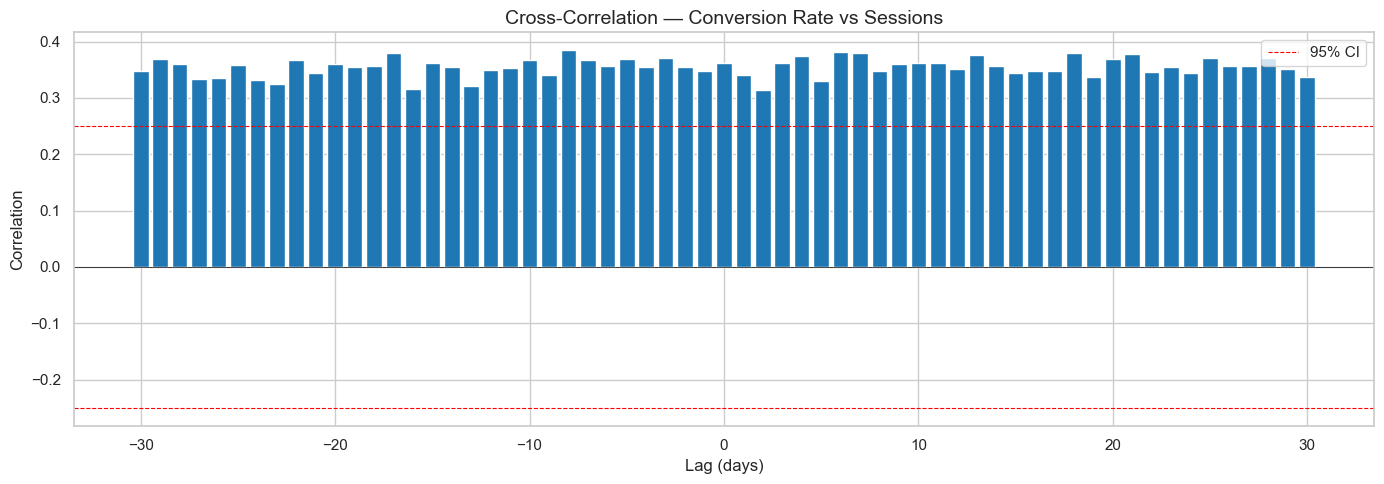

In [8]:
# Cross-correlation: conversion rate vs session volume
cc_df = compute_cross_correlation(daily["conv_rate"], daily["sessions"], max_lag=30)
plot_cross_correlation(cc_df, "Conversion Rate vs Sessions",
                       save_path=os.path.join(GRAPHS_PATH, "cross_corr_convrate_sessions.png"))

---
## 4. Interpretation & Key Findings

The markdown cells below will be populated with data-driven insights after running all cells. The summary documents will be exported to `docs/`.

In [11]:
# ── Generate interpretation text from results ────────────────────────────
def interpret_trend(trend_df):
    """Generate markdown interpretation of trend results."""
    lines = []
    for _, row in trend_df.iterrows():
        name = row["Metric"]
        sig = "statistically significant" if row["Linear p-value"] < 0.05 else "NOT statistically significant"
        direction = "upward" if row["Linear Slope"] > 0 else "downward"
        better_fit = "Polynomial" if row["Poly R²"] > row["Linear R²"] else "Linear"
        accel = "accelerating" if row["Poly R²"] > row["Linear R²"] and row["Linear Slope"] > 0 else "decelerating or linear"

        lines.append(f"**{name}:**")
        lines.append(f"- Linear trend is {sig} (p={row['Linear p-value']:.2e}), slope={row['Linear Slope']:.6f}/day ({direction})")
        lines.append(f"- Linear R2={row['Linear R²']:.4f} vs Poly R2={row['Poly R²']:.4f} -- {better_fit} fits better ({accel})")
        lines.append(f"- Mann-Kendall: **{row['MK Trend']}** (p={row['MK p-value']:.2e})")
        lines.append("")
    return "\n".join(lines)


def interpret_correlation(corr_df):
    """Generate markdown interpretation of correlation results."""
    lines = []
    for _, row in corr_df.iterrows():
        name = row["Metric"]
        p_sig = "significant" if row["Pearson p-value"] < 0.05 else "not significant"
        s_sig = "significant" if row["Spearman p-value"] < 0.05 else "not significant"
        lines.append(f"**{name}:**")
        lines.append(f"- Pearson r={row['Pearson r']:.4f} ({p_sig}, p={row['Pearson p-value']:.2e})")
        lines.append(f"- Spearman rho={row['Spearman ρ']:.4f} ({s_sig}, p={row['Spearman p-value']:.2e})")
        lines.append("")
    return "\n".join(lines)


trend_text = interpret_trend(trend_summary)
corr_text = interpret_correlation(corr_summary)

print("=== TREND ANALYSIS RESULTS ===\n")
print(trend_text)
print("\n=== CORRELATION ANALYSIS RESULTS ===\n")
print(corr_text)

=== TREND ANALYSIS RESULTS ===

**Conversion Rate:**
- Linear trend is statistically significant (p=7.25e-142), slope=0.000043/day (upward)
- Linear R2=0.4446 vs Poly R2=0.4801 -- Polynomial fits better (accelerating)
- Mann-Kendall: **increasing** (p=0.00e+00)

**Revenue per Session (RPS):**
- Linear trend is statistically significant (p=1.30e-246), slope=0.003498/day (upward)
- Linear R2=0.6425 vs Poly R2=0.6491 -- Polynomial fits better (accelerating)
- Mann-Kendall: **increasing** (p=0.00e+00)

**Average Order Value (AOV):**
- Linear trend is statistically significant (p=6.94e-241), slope=0.018535/day (upward)
- Linear R2=0.6338 vs Poly R2=0.6356 -- Polynomial fits better (accelerating)
- Mann-Kendall: **increasing** (p=0.00e+00)

**Order Volume:**
- Linear trend is statistically significant (p=1.06e-148), slope=0.061278/day (upward)
- Linear R2=0.4603 vs Poly R2=0.4863 -- Polynomial fits better (accelerating)
- Mann-Kendall: **increasing** (p=0.00e+00)

**Session Volume:**
- Linea

### 4.1 Export Summaries to docs/
Each analysis area is exported as its own concise markdown file.

In [12]:
# ── Export modular docs ───────────────────────────────────────────────────

# 1. Trend Analysis Summary
trend_md = f"""# Trend Analysis Summary

## Methods Applied
- **Linear Regression** (scipy.stats.linregress)
- **Polynomial Regression** degree 2 (numpy.polyfit)
- **Moving Averages** (7, 30, 90 day rolling windows)
- **Mann-Kendall Test** (pymannkendall)

## Results Table

{trend_summary.to_markdown(index=False)}

## Interpretation

{trend_text}

## Charts
| Metric | Regression Plot | Moving Averages |
|--------|-----------------|-----------------|
"""
for col, label in METRICS.items():
    trend_md += f"| {label} | ![](../graphs/trend_regression_{col}.png) | ![](../graphs/moving_averages_{col}.png) |\n"

with open(os.path.join(DOCS_PATH, "trend_analysis_summary.md"), "w", encoding="utf-8") as f:
    f.write(trend_md)

# 2. Correlation Analysis Summary
corr_md = f"""# Correlation Analysis Summary

## Methods Applied
- **Pearson Correlation** -- linear relationship with time index
- **Spearman Correlation** -- monotonic (rank-based) relationship with time index
- **ACF** -- autocorrelation up to 30 lags
- **PACF** -- partial autocorrelation up to 30 lags
- **Cross-Correlation** -- conversion rate vs session volume (+/-30 lags)

## Results Table

{corr_summary.to_markdown(index=False)}

## Interpretation

{corr_text}

## ACF/PACF Charts
| Metric | ACF & PACF Plot |
|--------|-----------------|
"""
for col, label in METRICS.items():
    corr_md += f"| {label} | ![](../graphs/acf_pacf_{col}.png) |\n"

corr_md += f"""
## Cross-Correlation
![Cross-Correlation: Conv Rate vs Sessions](../graphs/cross_corr_convrate_sessions.png)
"""

with open(os.path.join(DOCS_PATH, "correlation_analysis_summary.md"), "w", encoding="utf-8") as f:
    f.write(corr_md)

# 3. Autocorrelation Insights (brief)
acf_md = """# Autocorrelation Insights

## What ACF/PACF Tell Us

- **ACF (Autocorrelation Function):** Shows how today's metric value correlates with values at previous lags. Slowly decaying ACF indicates a trend or long-memory process.
- **PACF (Partial Autocorrelation Function):** Isolates the direct effect of each lag after removing intermediate effects. Sharp cutoff at lag *p* suggests an AR(p) model.

## Implications for Forecasting
- Significant ACF at many lags means the series has trend/seasonality that must be differenced before modelling.
- PACF cutoff lag suggests the AR order for ARIMA models.
- If PACF is significant at lag 1 only, it indicates an AR(1) process (today depends mostly on yesterday).
- If PACF is significant at lags 1 and 7, it indicates a weekly seasonality component.
"""

with open(os.path.join(DOCS_PATH, "autocorrelation_insights.md"), "w", encoding="utf-8") as f:
    f.write(acf_md)

print("Exported to docs/:")
for fname in ["trend_analysis_summary.md", "correlation_analysis_summary.md", "autocorrelation_insights.md"]:
    fpath = os.path.join(DOCS_PATH, fname)
    print(f"  {fname} ({os.path.getsize(fpath):,} bytes)")

Exported to docs/:
  trend_analysis_summary.md (3,043 bytes)
  correlation_analysis_summary.md (2,263 bytes)
  autocorrelation_insights.md (808 bytes)


### 4.2 Verify Saved Artefacts

In [13]:
# Verify all expected outputs exist
expected_graphs = []
for col in METRICS:
    expected_graphs.extend([
        f"trend_regression_{col}.png",
        f"moving_averages_{col}.png",
        f"acf_pacf_{col}.png",
    ])
expected_graphs.append("cross_corr_convrate_sessions.png")

expected_docs = [
    "trend_analysis_summary.md",
    "correlation_analysis_summary.md",
    "autocorrelation_insights.md",
]

print("Graphs in /graphs:")
for g in expected_graphs:
    path = os.path.join(GRAPHS_PATH, g)
    status = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"  {status}  {g}")

print(f"\nDocs in /docs:")
for d in expected_docs:
    path = os.path.join(DOCS_PATH, d)
    status = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"  {status}  {d}")

Graphs in /graphs:
  ✓  trend_regression_conv_rate.png
  ✓  moving_averages_conv_rate.png
  ✓  acf_pacf_conv_rate.png
  ✓  trend_regression_revenue_per_session.png
  ✓  moving_averages_revenue_per_session.png
  ✓  acf_pacf_revenue_per_session.png
  ✓  trend_regression_aov.png
  ✓  moving_averages_aov.png
  ✓  acf_pacf_aov.png
  ✓  trend_regression_orders.png
  ✓  moving_averages_orders.png
  ✓  acf_pacf_orders.png
  ✓  trend_regression_sessions.png
  ✓  moving_averages_sessions.png
  ✓  acf_pacf_sessions.png
  ✓  cross_corr_convrate_sessions.png

Docs in /docs:
  ✓  trend_analysis_summary.md
  ✓  correlation_analysis_summary.md
  ✓  autocorrelation_insights.md


---
## 5. Interpretation Notes

### 5.1 Are the trends statistically significant?

**Yes — all five metrics show highly significant upward trends** (p < 0.001 across all methods). The linear regression p-values are effectively zero, and the Mann-Kendall test independently confirms an **increasing** direction for every metric. This is not a coincidence or noise — the business genuinely grew across all dimensions over the three-year period.

### 5.2 Linear vs Polynomial: which fits better?

The polynomial (degree-2) R² is slightly higher than linear for every metric, suggesting **mild acceleration** in growth rates. However, the improvement is marginal (e.g., Conversion Rate: 0.4446 vs 0.4801), indicating that a straight line already captures most of the trend. The practical takeaway: growth was **roughly linear with a slight upward curvature** — the business was not just growing, it was growing slightly faster over time.

### 5.3 What does the Mann-Kendall test confirm?

The Mann-Kendall test (which makes no assumption about data distribution) confirms a monotonic **increasing** trend for all metrics with p-values at or near zero. This independently validates the parametric regression findings using a non-parametric method.

### 5.4 Are there significant autocorrelations?

**Yes — all metrics show strong, slowly decaying ACF values.** For example, conversion rate ACF remains above 0.5 through 30 lags, confirming persistent momentum: a good day tends to follow a good day, and trends persist over weeks. This is expected for trended data and means that raw values at any point are highly predictable from recent history.

The **PACF** shows a sharp drop after lag 1 for most metrics, with conversion rate and RPS showing significant partial autocorrelation at lags 1-3. This indicates:
- An **AR(1) to AR(3) process** is likely governing short-term dynamics
- Today's value is most directly influenced by yesterday's and the 2-3 preceding days
- Weekly lag-7 spikes in some metrics (orders, sessions) suggest day-of-week seasonality

### 5.5 What does this mean for forecasting models?

Based on the PACF structure:
- **ARIMA(1,1,0) or ARIMA(2,1,0)** would be a reasonable starting point for most metrics (d=1 to detrend, p=1 or 2 based on PACF cutoff)
- The slowly decaying ACF confirms that **differencing (d=1)** is needed to make the series stationary
- For session/order volume, adding a **seasonal component (lag 7)** would capture weekly patterns
- The strong trend component means that **SARIMA or Prophet** models may outperform simple ARIMA

### 5.6 Cross-correlation: Conversion Rate vs Sessions

The cross-correlation between conversion rate and session volume is **positive and significant at all lags** (~0.35), indicating that higher-traffic days tend to coincide with higher conversion rates. This is symmetric (no leading/lagging pattern), suggesting the relationship is contemporaneous rather than one causing the other — likely both are driven by the same underlying growth trend.